# ML Classification - Olist E-commerce Database

# Modelling

# Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno
import sqlalchemy
from sqlalchemy import create_engine, MetaData, Table, inspect
from scipy.stats import boxcox
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score ,silhouette_score, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV,\
    KFold, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import recall_score, f1_score, classification_report,\
    confusion_matrix, roc_curve, roc_auc_score, make_scorer, precision_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Models

## Random Forest

### Import File

In [ ]:
 # Upload the "features_table.csv" that was originated at the end of "ML_Olist_Data_Preparation".
 # Copy the path and paste inside de pd.read_csv function below
rf_df = pd.read_csv("/content/features_table.csv")

seed = 123

In [ ]:
rf_df.head()

,customer_unique_id,retention,tt_product_qty,tt_freight,avg_waiting_days,avg_del_comp_days,avg_review_score,purch_d_n,purch_wd,pay_type,sp_rj_mg_or_other,cluster
0,0000f46a3911fa3c0805444483337064,0,1,17.22,26.0,1.0,3.0,night,weekdays,credit_card,other_state,1
1,0005e1862207bf6ccc02e4228effd9a0,0,1,15.12,4.0,28.0,4.0,night,weekend,credit_card,sp_rj_mg,0
2,00115fc7123b5310cf6d3a3aa932699e,0,1,16.12,11.0,32.0,4.0,night,weekend,credit_card,other_state,0
3,0011805441c0d1b68b48002f1d005526,0,1,28.14,18.0,12.0,3.0,day,weekdays,credit_card,other_state,1
4,00191a9719ef48ebb5860b130347bf33,0,1,10.96,15.0,18.0,3.0,day,weekdays,credit_card,sp_rj_mg,2


In [ ]:
# Change cluster type
rf_df["cluster"] = rf_df["cluster"].astype("O")

# Inspect
rf_df.info()
rf_df.isna().sum()

rf_df = rf_df[rf_df["pay_type"] != "0"]

rf_df["pay_type"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB


,count
pay_type,
credit_card,8052
boleto,2311
voucher,234
debit_card,105


### Iteration 1: All Features (overfitting)

#### Train / Test Split

Define Features and Target

In [ ]:
# Features
X = rf_df.drop(["retention", "customer_unique_id"], axis = 1)

# Target
y = rf_df["retention"]

Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer()

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2076    1]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2077
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2141
   macro avg       0.49      0.50      0.49      2141
weighted avg       0.94      0.97      0.96      2141



ROC AUC Area:  0.5


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [100, 200, 300, 400, 500],
    "rf_model__max_depth": [2, 5, 10, 15],
    "rf_model__min_samples_leaf": [0.02, 0.04, 0.06, 0.08],
    "rf_model__max_features": [0.2, 0.4,0.6, 0.8],
    "rf_model__class_weight": ["balanced", "balanced_subsample"]}

# Shuffle and split the data
kf = KFold(n_splits = 5, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 10,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['purch_d_n', 'purch_wd', 'pay_type', 'sp_rj_mg_or_other', 'cluster'], dtype='object')),
                                                                              ('num',
                                                                               SimpleImputer(),
                                                                               Index(['tt_product_qty', 'tt_freight...
      dtype='object'))])),
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample'],
                                        'rf_model__max_depth': [2, 5, 10, 15],
                                        'rf_model__max_features': [0.2, 0.4,
                                                                   0.6, 0.8],
                                        'rf_model__min_samples_leaf': [0.02,
                                                                       0.04,
                                                                       0.06,
                                                                       0.08],
                                        'rf_model__n_estimators': [100, 200,
                                                                   300, 400,
                                                                   500]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 300, 'rf_model__min_samples_leaf': 0.08, 'rf_model__max_features': 0.6, 'rf_model__max_depth': 2, 'rf_model__class_weight': 'balanced'}


Best CV score (recall): nan


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.671


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: nan
Train Recall: 0.469
Test Recall: 0.391


Confusion Matrix

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred_test))



[[1412  665]
 [  39   25]]


              precision    recall  f1-score   support

           0       0.97      0.68      0.80      2077
           1       0.04      0.39      0.07        64

    accuracy                           0.67      2141
   macro avg       0.50      0.54      0.43      2141
weighted avg       0.95      0.67      0.78      2141



ROC Curve / AUC

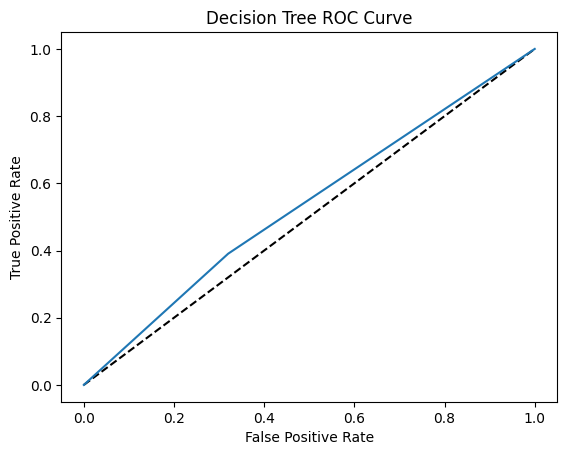



ROC AUC Area:  0.535


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

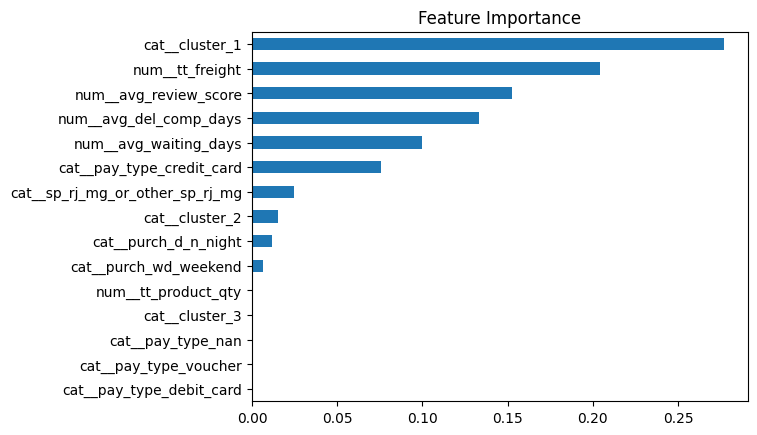

In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = feature_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh")
plt.title("Feature Importance")
plt.show()

### Iteration 1.1 (Adjusting hyperparameters)

#### Train / Test Split

Define Features and Target

In [ ]:
# Features
X = rf_df.drop(["retention", "customer_unique_id"], axis = 1)

# Target
y = rf_df["retention"]

Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer()

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2076    1]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2077
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2141
   macro avg       0.49      0.50      0.49      2141
weighted avg       0.94      0.97      0.96      2141



ROC AUC Area:  0.5


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [40, 50, 100, 120],
    "rf_model__max_depth": [2, 3, 4, 5],
    "rf_model__min_samples_leaf": [0.1, 0.2, 0.22, 0.25],
    "rf_model__max_features": [5, 6, 7, 8, 9, 10],
    "rf_model__class_weight": ["balanced", "balanced_subsample", None]}

# Shuffle and split the data
kf = KFold(n_splits = 10, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 30,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['purch_d_n', 'purch_wd', 'pay_type', 'sp_rj_mg_or_other', 'cluster'], dtype='object')),
                                                                              ('num',
                                                                               SimpleImputer(),
                                                                               Index(['tt_product_qty', 'tt_freigh...
      dtype='object'))])),
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   n_iter=30,
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample',
                                                                   None],
                                        'rf_model__max_depth': [2, 3, 4, 5],
                                        'rf_model__max_features': [5, 6, 7, 8,
                                                                   9, 10],
                                        'rf_model__min_samples_leaf': [0.1, 0.2,
                                                                       0.22,
                                                                       0.25],
                                        'rf_model__n_estimators': [40, 50, 100,
                                                                   120]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 100, 'rf_model__min_samples_leaf': 0.22, 'rf_model__max_features': 8, 'rf_model__max_depth': 4, 'rf_model__class_weight': 'balanced'}


Best CV score (recall): nan


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.606


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: nan
Train Recall: 0.465
Test Recall: 0.422


Confusion Matrix

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred_test))



[[1271  806]
 [  37   27]]


              precision    recall  f1-score   support

           0       0.97      0.61      0.75      2077
           1       0.03      0.42      0.06        64

    accuracy                           0.61      2141
   macro avg       0.50      0.52      0.41      2141
weighted avg       0.94      0.61      0.73      2141



ROC Curve / AUC

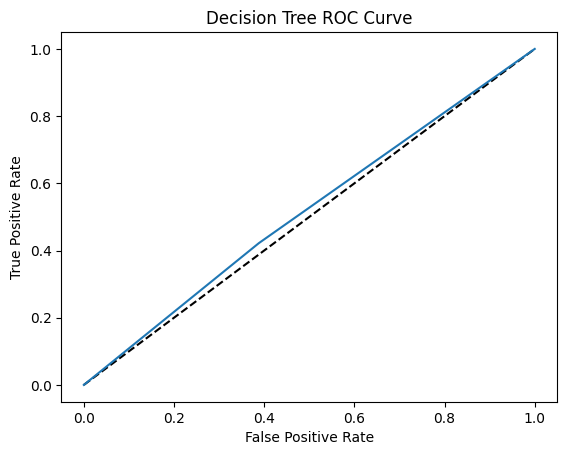



ROC AUC Area:  0.517


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

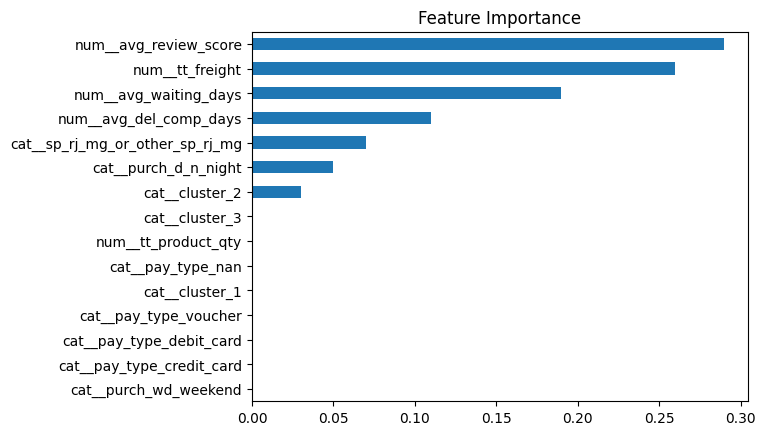

In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = feature_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh")
plt.title("Feature Importance")
plt.show()

### Iteration 2 (low results)

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Features
X = rf_df[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days",
           "purch_d_n",
           "purch_wd",
           "sp_rj_mg_or_other"]]

# Target
y = rf_df["retention"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB


Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer()

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2076    1]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2077
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2141
   macro avg       0.49      0.50      0.49      2141
weighted avg       0.94      0.97      0.96      2141



ROC AUC Area:  0.5


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [100, 200, 300, 400, 500],
    "rf_model__max_depth": [2, 5, 10, 15],
    "rf_model__min_samples_leaf": [0.02, 0.04, 0.06, 0.08],
    "rf_model__max_features": [0.2, 0.4,0.6, 0.8],
    "rf_model__class_weight": ["balanced", "balanced_subsample"]}

# Shuffle and split the data
kf = KFold(n_splits = 5, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 10,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['cluster', 'purch_d_n', 'purch_wd', 'sp_rj_mg_or_other'], dtype='object')),
                                                                              ('num',
                                                                               SimpleImputer(),
                                                                               Index(['avg_del_comp_days', 'avg_review_score',...
      dtype='object'))])),
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample'],
                                        'rf_model__max_depth': [2, 5, 10, 15],
                                        'rf_model__max_features': [0.2, 0.4,
                                                                   0.6, 0.8],
                                        'rf_model__min_samples_leaf': [0.02,
                                                                       0.04,
                                                                       0.06,
                                                                       0.08],
                                        'rf_model__n_estimators': [100, 200,
                                                                   300, 400,
                                                                   500]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 400, 'rf_model__min_samples_leaf': 0.08, 'rf_model__max_features': 0.2, 'rf_model__max_depth': 2, 'rf_model__class_weight': 'balanced_subsample'}


Best CV score (recall): 0.388


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.681


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: 0.388
Train Recall: 0.469
Test Recall: 0.453


Confusion Matrix

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred_test))



[[1430  647]
 [  35   29]]


              precision    recall  f1-score   support

           0       0.98      0.69      0.81      2077
           1       0.04      0.45      0.08        64

    accuracy                           0.68      2141
   macro avg       0.51      0.57      0.44      2141
weighted avg       0.95      0.68      0.79      2141



ROC Curve / AUC

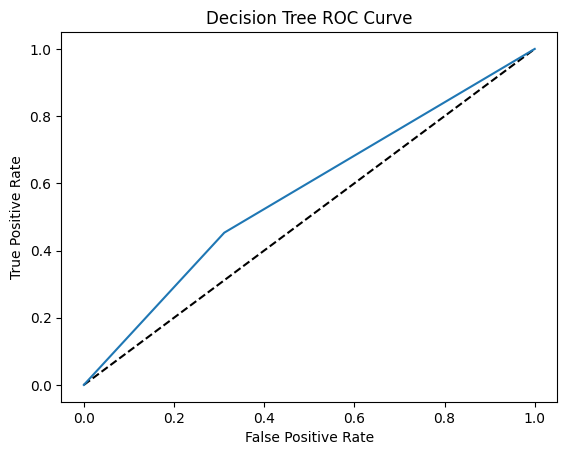



ROC AUC Area:  0.571


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

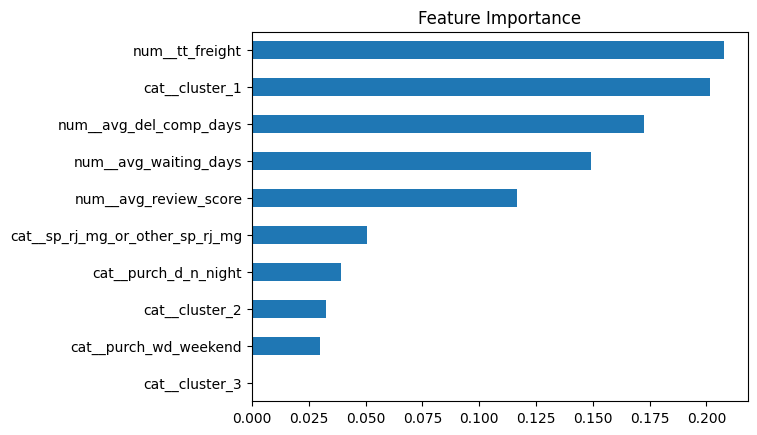

In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = feature_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh")
plt.title("Feature Importance")
plt.show()

### Iteration 2.1 (change hyperparameters)

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Features
X = rf_df[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days",
           "purch_d_n",
           "purch_wd",
           "sp_rj_mg_or_other"]]

# Target
y = rf_df["retention"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB


Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer()

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2076    1]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2077
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2141
   macro avg       0.49      0.50      0.49      2141
weighted avg       0.94      0.97      0.96      2141



ROC AUC Area:  0.5


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [50, 100, 150, 200],
    "rf_model__max_depth": [3, 4, 5, 6, 8],
    "rf_model__min_samples_leaf": [0.2, 0.22, 0.25, 0.27, 0.3],
    "rf_model__max_features": [1, 2, 3, 4, 5, 6, 7, 8],    # not relevant as they are only few
    "rf_model__class_weight": ["balanced", "balanced_subsample", None]}

# Shuffle and split the data
kf = KFold(n_splits = 10, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 30,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['cluster', 'purch_d_n', 'purch_wd', 'sp_rj_mg_or_other'], dtype='object')),
                                                                              ('num',
                                                                               SimpleImputer(),
                                                                               Index(['avg_del_comp_days', 'avg_review_score'...
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   n_iter=30,
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample',
                                                                   None],
                                        'rf_model__max_depth': [3, 4, 5, 6, 8],
                                        'rf_model__max_features': [1, 2, 3, 4,
                                                                   5, 6, 7, 8],
                                        'rf_model__min_samples_leaf': [0.2,
                                                                       0.22,
                                                                       0.25,
                                                                       0.27,
                                                                       0.3],
                                        'rf_model__n_estimators': [50, 100, 150,
                                                                   200]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 50, 'rf_model__min_samples_leaf': 0.25, 'rf_model__max_features': 6, 'rf_model__max_depth': 3, 'rf_model__class_weight': 'balanced'}


Best CV score (recall): 0.586


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.507


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: 0.586
Train Recall: 0.589
Test Recall: 0.625


Confusion Matrix

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred_test))



[[1046 1031]
 [  24   40]]


              precision    recall  f1-score   support

           0       0.98      0.50      0.66      2077
           1       0.04      0.62      0.07        64

    accuracy                           0.51      2141
   macro avg       0.51      0.56      0.37      2141
weighted avg       0.95      0.51      0.65      2141



ROC Curve / AUC

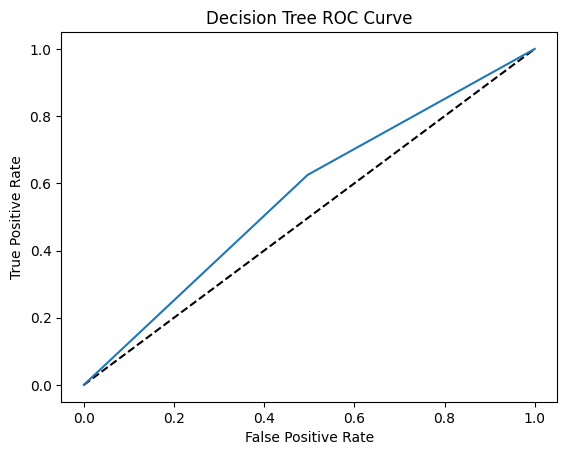



ROC AUC Area:  0.564


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

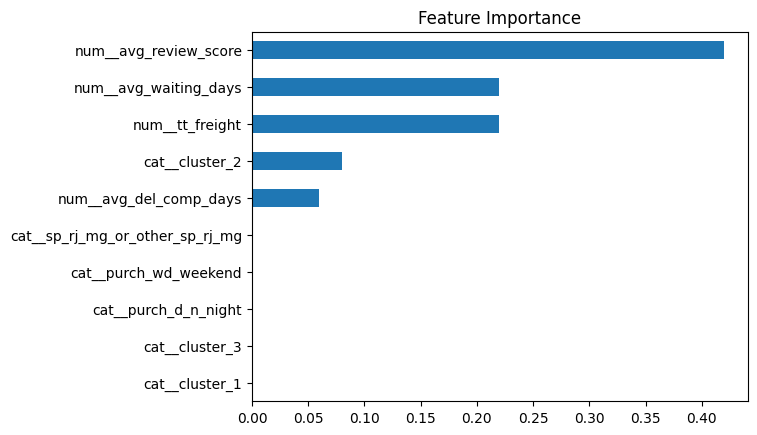

In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = feature_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh")
plt.title("Feature Importance")
plt.show()

### Iteration 3

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Features
X = rf_df[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days"]]

# Target
y = rf_df["retention"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB


Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer()

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2074    3]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2077
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2141
   macro avg       0.49      0.50      0.49      2141
weighted avg       0.94      0.97      0.95      2141



ROC AUC Area:  0.499


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [100, 200, 300, 400, 500],
    "rf_model__max_depth": [2, 5, 10, 15],
    "rf_model__min_samples_leaf": [0.02, 0.04, 0.06, 0.08],
    "rf_model__max_features": [0.2, 0.4,0.6, 0.8],
    "rf_model__class_weight": ["balanced", "balanced_subsample"]}

# Shuffle and split the data
kf = KFold(n_splits = 5, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 10,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['cluster'], dtype='object')),
                                                                              ('num',
                                                                               SimpleImputer(),
                                                                               Index(['avg_del_comp_days', 'avg_review_score', 'tt_freight',
       'avg_waiting_days'],
      dtype='obj...])),
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample'],
                                        'rf_model__max_depth': [2, 5, 10, 15],
                                        'rf_model__max_features': [0.2, 0.4,
                                                                   0.6, 0.8],
                                        'rf_model__min_samples_leaf': [0.02,
                                                                       0.04,
                                                                       0.06,
                                                                       0.08],
                                        'rf_model__n_estimators': [100, 200,
                                                                   300, 400,
                                                                   500]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 200, 'rf_model__min_samples_leaf': 0.06, 'rf_model__max_features': 0.2, 'rf_model__max_depth': 2, 'rf_model__class_weight': 'balanced_subsample'}


Best CV score (recall): 0.428


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.606


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: 0.428
Train Recall: 0.535
Test Recall: 0.438


Confusion Matrix

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred_test))



[[1270  807]
 [  36   28]]


              precision    recall  f1-score   support

           0       0.97      0.61      0.75      2077
           1       0.03      0.44      0.06        64

    accuracy                           0.61      2141
   macro avg       0.50      0.52      0.41      2141
weighted avg       0.94      0.61      0.73      2141



ROC Curve / AUC

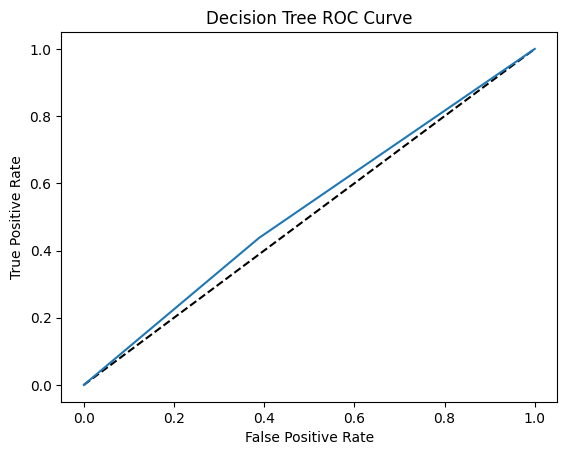



ROC AUC Area:  0.524


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

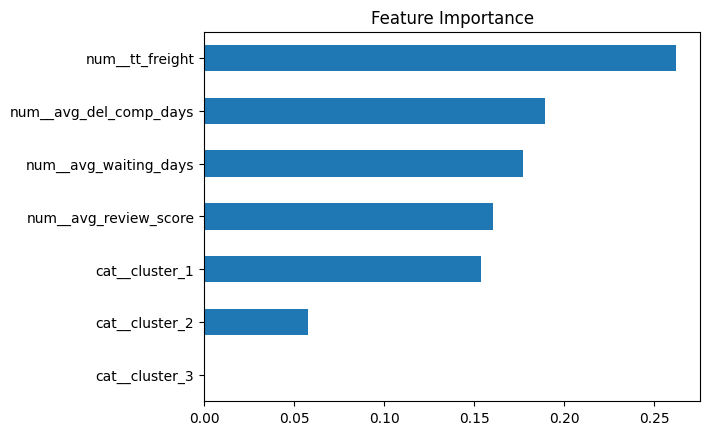

In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = feature_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh")
plt.title("Feature Importance")
plt.show()

### Iteration 3.1 (change hyperparameters)

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Features
X = rf_df[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days"]]

# Target
y = rf_df["retention"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB


Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer()

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2074    3]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2077
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2141
   macro avg       0.49      0.50      0.49      2141
weighted avg       0.94      0.97      0.95      2141



ROC AUC Area:  0.499


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [40, 50, 100, 120],
    "rf_model__max_depth": [2, 3, 4, 5],
    "rf_model__min_samples_leaf": [0.1, 0.2, 0.22, 0.25],
    "rf_model__max_features": [0.1, 0.15, 0.17, 0.19, 0.2],
    "rf_model__class_weight": ["balanced", "balanced_subsample", None]}

# Shuffle and split the data
kf = KFold(n_splits = 10, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 30,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['cluster'], dtype='object')),
                                                                              ('num',
                                                                               SimpleImputer(),
                                                                               Index(['avg_del_comp_days', 'avg_review_score', 'tt_freight',
       'avg_waiting_days'],
      dtype='ob...
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   n_iter=30,
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample',
                                                                   None],
                                        'rf_model__max_depth': [2, 3, 4, 5],
                                        'rf_model__max_features': [0.1, 0.15,
                                                                   0.17, 0.19,
                                                                   0.2],
                                        'rf_model__min_samples_leaf': [0.1, 0.2,
                                                                       0.22,
                                                                       0.25],
                                        'rf_model__n_estimators': [40, 50, 100,
                                                                   120]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 40, 'rf_model__min_samples_leaf': 0.22, 'rf_model__max_features': 0.19, 'rf_model__max_depth': 4, 'rf_model__class_weight': 'balanced_subsample'}


Best CV score (recall): 0.533


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.568


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: 0.533
Train Recall: 0.527
Test Recall: 0.484


Confusion Matrix

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred_test))



[[1186  891]
 [  33   31]]


              precision    recall  f1-score   support

           0       0.97      0.57      0.72      2077
           1       0.03      0.48      0.06        64

    accuracy                           0.57      2141
   macro avg       0.50      0.53      0.39      2141
weighted avg       0.94      0.57      0.70      2141



ROC Curve / AUC

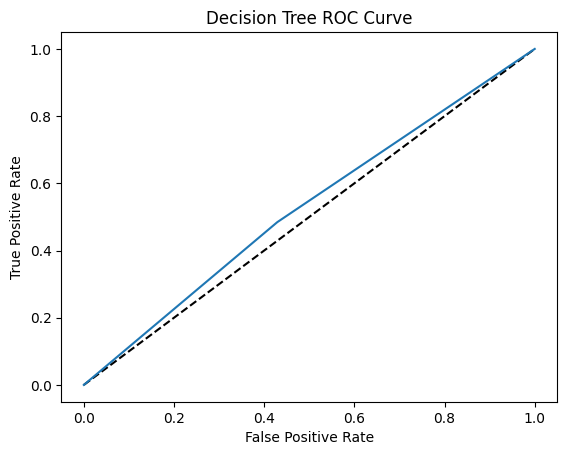



ROC AUC Area:  0.528


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

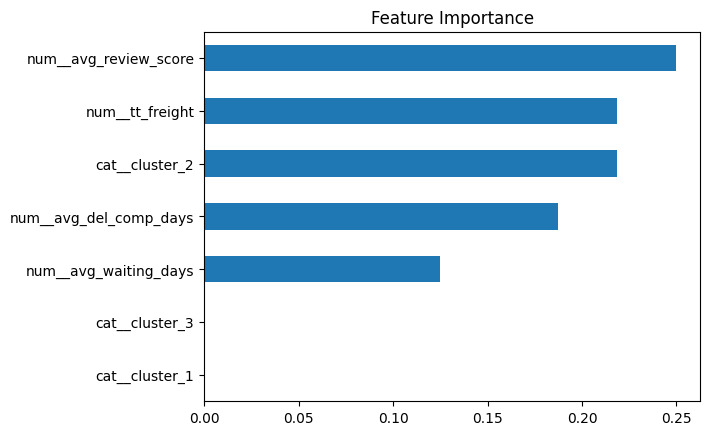

In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = feature_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh")
plt.title("Feature Importance")
plt.show()

### Iteration 3.2

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Features
X = rf_df[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days"]]

# Target
y = rf_df["retention"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB


Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer()

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2074    3]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2077
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2141
   macro avg       0.49      0.50      0.49      2141
weighted avg       0.94      0.97      0.95      2141



ROC AUC Area:  0.499


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [100, 150, 200, 250, 300],
    "rf_model__max_depth": [2, 3, 4, 5, 6, 8],
    "rf_model__min_samples_leaf": [0.2, 0.22, 0.25, 0.27, 0.3],
    "rf_model__max_features": [1, 2, 3, 4, 5],    # not relevant as they are only few
    "rf_model__class_weight": ["balanced", "balanced_subsample", None]}

# Shuffle and split the data
kf = KFold(n_splits = 10, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 30,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['cluster'], dtype='object')),
                                                                              ('num',
                                                                               SimpleImputer(),
                                                                               Index(['avg_del_comp_days', 'avg_review_score', 'tt_freight',
       'avg_waiting_days'],
      dtype='ob...
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   n_iter=30,
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample',
                                                                   None],
                                        'rf_model__max_depth': [2, 3, 4, 5, 6,
                                                                8],
                                        'rf_model__max_features': [1, 2, 3, 4,
                                                                   5],
                                        'rf_model__min_samples_leaf': [0.2,
                                                                       0.22,
                                                                       0.25,
                                                                       0.27,
                                                                       0.3],
                                        'rf_model__n_estimators': [100, 150,
                                                                   200, 250,
                                                                   300]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 300, 'rf_model__min_samples_leaf': 0.25, 'rf_model__max_features': 4, 'rf_model__max_depth': 8, 'rf_model__class_weight': 'balanced'}


Best CV score (recall): 0.534


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.553


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: 0.534
Train Recall: 0.531
Test Recall: 0.562


Confusion Matrix

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred_test))



[[1147  930]
 [  28   36]]


              precision    recall  f1-score   support

           0       0.98      0.55      0.71      2077
           1       0.04      0.56      0.07        64

    accuracy                           0.55      2141
   macro avg       0.51      0.56      0.39      2141
weighted avg       0.95      0.55      0.69      2141



ROC Curve / AUC

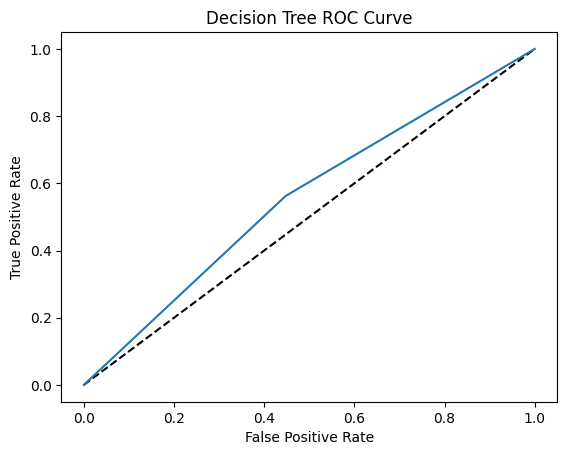



ROC AUC Area:  0.557


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

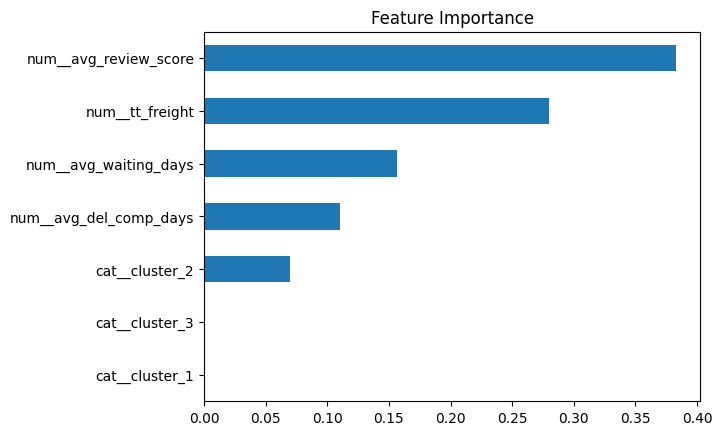

In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = feature_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh")
plt.title("Feature Importance")
plt.show()

### Iteration 3.3 (imputation with median)

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Features
X = rf_df[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days"]]

# Target
y = rf_df["retention"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB


Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer(strategy = "median")

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2074    3]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2077
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2141
   macro avg       0.49      0.50      0.49      2141
weighted avg       0.94      0.97      0.95      2141



ROC AUC Area:  0.499


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [100, 150, 200, 250, 300],
    "rf_model__max_depth": [2, 3, 4, 5, 6, 8],
    "rf_model__min_samples_leaf": [0.2, 0.22, 0.25, 0.27, 0.3],
    "rf_model__max_features": [1, 2, 3, 4, 5],    # not relevant as they are only few
    "rf_model__class_weight": ["balanced", "balanced_subsample", None]}

# Shuffle and split the data
kf = KFold(n_splits = 10, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 30,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

Confusion Matrix

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred_test))



ROC Curve / AUC

In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = feature_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh")
plt.title("Feature Importance")
plt.show()

### Iteration 3.3.1 (remove clusters)

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Features
X = rf_df[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days"]]

# Target
y = rf_df["retention"]

Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# remove drop = "first"
ohe = OneHotEncoder()

Imputation

In [ ]:
# By default the strategy is mean
imp_num = SimpleImputer(strategy = "median")

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

# Select numerical features
X_num = X.select_dtypes(include = "number")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns),
        ("num", imp_num, X_num.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
          ("column_remover", FunctionTransformer(lambda array: pd.DataFrame(array).drop(
            columns = [0, 2, 3]))),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Check names to remove the correct index and keep cluster_1
print(pipeline.named_steps['preprocessor'].get_feature_names_out())

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [100, 150, 200, 250, 300],
    "rf_model__max_depth": [2, 3, 4, 5, 6, 8],
    "rf_model__min_samples_leaf": [0.2, 0.22, 0.25, 0.27, 0.3],
    "rf_model__max_features": [1, 2, 3, 4, 5],    # not relevant as they are only few
    "rf_model__class_weight": ["balanced", "balanced_subsample", None]}

# Shuffle and split the data
kf = KFold(n_splits = 10, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 30,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(),
                                                                               Index(['cluster'], dtype='object')),
                                                                              ('num',
                                                                               SimpleImputer(strategy='median'),
                                                                               Index(['avg_del_comp_days', 'avg_review_score', 'tt_freight',
       'avg_waiting_days'],
      dtyp...
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   n_iter=30,
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample',
                                                                   None],
                                        'rf_model__max_depth': [2, 3, 4, 5, 6,
                                                                8],
                                        'rf_model__max_features': [1, 2, 3, 4,
                                                                   5],
                                        'rf_model__min_samples_leaf': [0.2,
                                                                       0.22,
                                                                       0.25,
                                                                       0.27,
                                                                       0.3],
                                        'rf_model__n_estimators': [100, 150,
                                                                   200, 250,
                                                                   300]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 300, 'rf_model__min_samples_leaf': 0.25, 'rf_model__max_features': 4, 'rf_model__max_depth': 8, 'rf_model__class_weight': 'balanced'}


Best CV score (recall): 0.608


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.417


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: 0.608
Train Recall: 0.671
Test Recall: 0.688


Confusion Matrix

[[ 848 1229]
 [  20   44]]




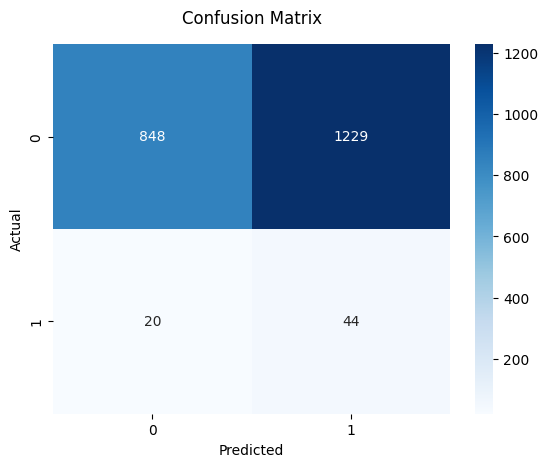

              precision    recall  f1-score   support

           0       0.98      0.41      0.58      2077
           1       0.03      0.69      0.07        64

    accuracy                           0.42      2141
   macro avg       0.51      0.55      0.32      2141
weighted avg       0.95      0.42      0.56      2141



In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

sns.heatmap(confusion_matrix(y_test, y_pred_test),
            annot=True,
            fmt='d',
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', pad = 15)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_test))



ROC Curve / AUC

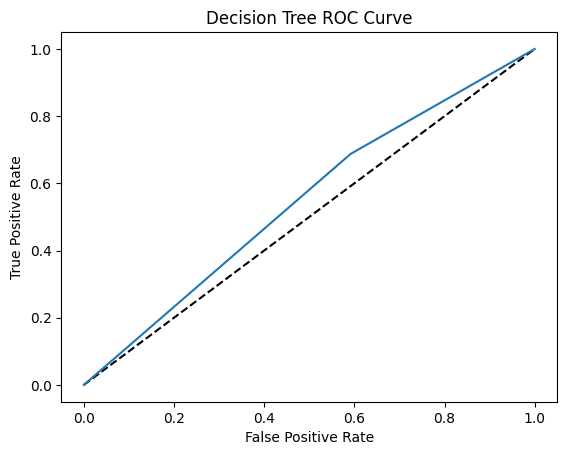



ROC AUC Area:  0.548


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

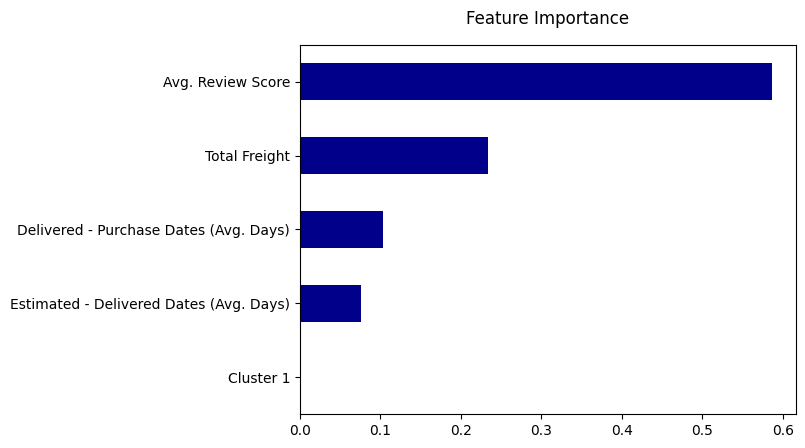

['cat__cluster_0', 'cat__cluster_1', 'cat__cluster_2', 'cat__cluster_3', 'num__avg_del_comp_days', 'num__avg_review_score', 'num__tt_freight', 'num__avg_waiting_days']


In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

new_names = [
    "Cluster 1", "Estimated - Delivered Dates (Avg. Days)",\
    "Avg. Review Score", "Total Freight", "Delivered - Purchase Dates (Avg. Days)"]

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = new_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh",
                           color = "#00008B")
plt.title("Feature Importance", pad = 15)
plt.show()

print(feature_names)
feature_names_name = feature_names[0]

### Iteration 3.4 (remove missing values)

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Removing missing values on review_score
rf_df_dropna = rf_df.dropna(subset = ["avg_review_score"])
rf_df_dropna.info()

# Features
X = rf_df_dropna[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days"]]

# Target
y = rf_df_dropna["retention"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 10623 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Co

Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# drop = "first" to eliminate one of the "dummies" and reduce multicollinearity
# handle_unknown = "ignore" ?
ohe = OneHotEncoder(drop = "first")

Imputation

In [ ]:
# No numerical imputation

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns)],
    remainder='passthrough')

#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [ ]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

##### Evaluating

In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2056    5]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2061
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2125
   macro avg       0.48      0.50      0.49      2125
weighted avg       0.94      0.97      0.95      2125



ROC AUC Area:  0.499


#### CV / RandomnizedSearch

In [ ]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [100, 150, 200, 250, 300],
    "rf_model__max_depth": [2, 3, 4, 5, 6, 8],
    "rf_model__min_samples_leaf": [0.2, 0.22, 0.25, 0.27, 0.3],
    "rf_model__max_features": [1, 2, 3, 4, 5],    # not relevant as they are only few
    "rf_model__class_weight": ["balanced", "balanced_subsample", None]}

# Shuffle and split the data
kf = KFold(n_splits = 10, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 30,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=KFold(n_splits=10, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['cluster'], dtype='object'))])),
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   n_iter=30,
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample',
                                                                   None],
                                        'rf_model__max_depth': [2, 3, 4, 5, 6,
                                                                8],
                                        'rf_model__max_features': [1, 2, 3, 4,
                                                                   5],
                                        'rf_model__min_samples_leaf': [0.2,
                                                                       0.22,
                                                                       0.25,
                                                                       0.27,
                                                                       0.3],
                                        'rf_model__n_estimators': [100, 150,
                                                                   200, 250,
                                                                   300]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [ ]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 300, 'rf_model__min_samples_leaf': 0.25, 'rf_model__max_features': 4, 'rf_model__max_depth': 8, 'rf_model__class_weight': 'balanced'}


Best CV score (recall): 0.599


#### Evaluating (Test Set)

Accuracy

In [ ]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.458


Generalization Error

In [ ]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: 0.599
Train Recall: 0.656
Test Recall: 0.578


Confusion Matrix

[[ 937 1124]
 [  27   37]]




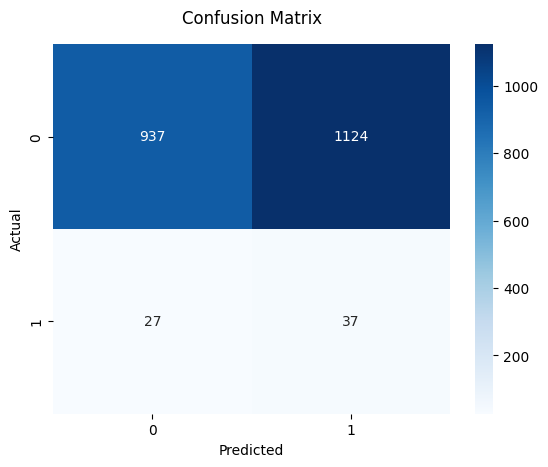

              precision    recall  f1-score   support

           0       0.97      0.45      0.62      2061
           1       0.03      0.58      0.06        64

    accuracy                           0.46      2125
   macro avg       0.50      0.52      0.34      2125
weighted avg       0.94      0.46      0.60      2125



In [ ]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

sns.heatmap(confusion_matrix(y_test, y_pred_test),
            annot=True,
            fmt='d',
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', pad = 15)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_test))



ROC Curve / AUC

<ipython-input-163-4e82e4c75293>:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color = "#ADD8E6")


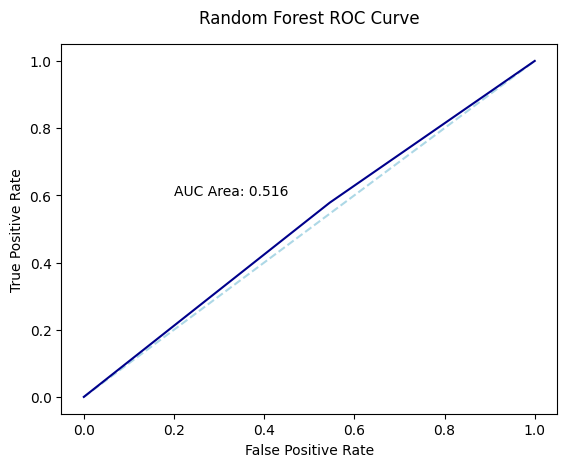



ROC AUC Area:  0.516


In [ ]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--', color = "#ADD8E6")
plt.plot(fpr, tpr, color = "#00008B")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.annotate(f"AUC Area: {roc_auc_score(y_test, y_pred_test).round(3)}", xy = (0.2, 0.6))
plt.title('Random Forest ROC Curve', pad = 15)
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

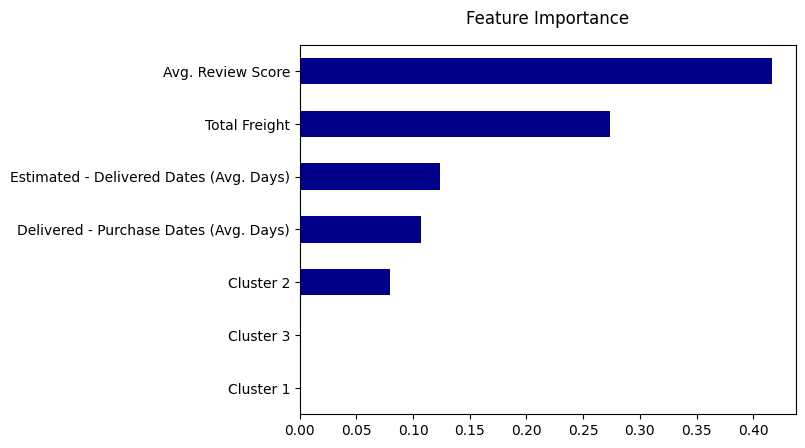

['cat__cluster_1', 'cat__cluster_2', 'cat__cluster_3', 'remainder__avg_del_comp_days', 'remainder__avg_review_score', 'remainder__tt_freight', 'remainder__avg_waiting_days']


In [ ]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

new_names = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Estimated - Delivered Dates (Avg. Days)', 'Avg. Review Score', 'Total Freight', 'Delivered - Purchase Dates (Avg. Days)']

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = new_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh",
                           color = "#00008B")
plt.title("Feature Importance", pad = 15)
plt.show()

print(feature_names)
feature_names_name = feature_names[0]

### Iteration 3.4.1 (Remove Clusters)

#### Train / Test Split

Define Features and Target

In [ ]:
rf_df.info()

# Removing missing values on review_score
rf_df_dropna = rf_df.dropna(subset = ["avg_review_score"])
rf_df_dropna.info()

# Features
X = rf_df_dropna[["avg_del_comp_days",
           "cluster",
           "avg_review_score",
           "tt_freight",
           "avg_waiting_days"]]

# Target
y = rf_df_dropna["retention"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 10623 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Co

Train / Test Split

In [ ]:
# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                   stratify = y, random_state = seed)


#### Transformations

One-Hot Enconding

In [ ]:
# One-hot encode categorical features for training and test sets separately
# We remove drop = "first"
ohe = OneHotEncoder()

Imputation

In [ ]:
# No numerical imputation

Define Columns

In [ ]:
# Select categorical features
X_cat = X.select_dtypes("O")

Preprocessor

In [ ]:
# This step is needed because we have different kind of imputations for
# categorical and numerical features
# remainder='passthrough' otherwise it will not get the other features
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', ohe, X_cat.columns)],
    remainder='passthrough')

# Remove irrelevant clusters


#### Random Forest Model

In [ ]:
rf = RandomForestClassifier(random_state = seed)

#### Pipeline

In [178]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("column_remover", FunctionTransformer(lambda array: pd.DataFrame(array).drop(
            columns = [0, 2, 3]))),
         ("rf_model", rf)])

# Fit
pipeline.fit(X_train, y_train)


# Predict
y_pred = pipeline.predict(X_test)

# Check names to remove the correct index and keep cluster_1
print(pipeline.named_steps['preprocessor'].get_feature_names_out())




['cat__cluster_0' 'cat__cluster_1' 'cat__cluster_2' 'cat__cluster_3'
 'remainder__avg_del_comp_days' 'remainder__avg_review_score'
 'remainder__tt_freight' 'remainder__avg_waiting_days']


##### Evaluating

In [179]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))
print("\n")

# Classification Report
print(classification_report(y_test, y_pred))
print("\n")

# ROC Curve /AUC
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred).round(3))

[[2058    3]
 [  64    0]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2061
           1       0.00      0.00      0.00        64

    accuracy                           0.97      2125
   macro avg       0.48      0.50      0.49      2125
weighted avg       0.94      0.97      0.95      2125



ROC AUC Area:  0.499


#### CV / RandomnizedSearch

In [180]:
# Define the grid of hyperparameters
params_rf = {
    'rf_model__n_estimators': [100, 150, 200, 250, 300],
    "rf_model__max_depth": [2, 3, 4, 5, 6, 8],
    "rf_model__min_samples_leaf": [0.2, 0.22, 0.25, 0.27, 0.3],
    "rf_model__max_features": [1, 2, 3, 4, 5],    # not relevant as they are only few
    "rf_model__class_weight": ["balanced", "balanced_subsample", None]}

# Shuffle and split the data
kf = KFold(n_splits = 10, shuffle = True, random_state = seed)

# CV
cv_rf = RandomizedSearchCV(estimator = pipeline,
                             param_distributions = params_rf,
                             scoring = "recall",
                             cv = kf,
                             n_iter = 30,
                             random_state = seed)

# Fit cv_rf to the training set
cv_rf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=KFold(n_splits=10, random_state=123, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(),
                                                                               Index(['cluster'], dtype='object'))])),
                                             ('column_remover',
                                              FunctionTransformer(func=<function <lambda> at 0x78bde84cdf80>)),
                                             ('rf_model',
                                              RandomForestClassifier(random_state=123))]),
                   n_iter=30,
                   param_distributions={'rf_model__class_weight': ['balanced',
                                                                   'balanced_subsample',
                                                                   None],
                                        'rf_model__max_depth': [2, 3, 4, 5, 6,
                                                                8],
                                        'rf_model__max_features': [1, 2, 3, 4,
                                                                   5],
                                        'rf_model__min_samples_leaf': [0.2,
                                                                       0.22,
                                                                       0.25,
                                                                       0.27,
                                                                       0.3],
                                        'rf_model__n_estimators': [100, 150,
                                                                   200, 250,
                                                                   300]},
                   random_state=123, scoring='recall')

##### Evaluating (CV)

In [181]:
# Extract best hyperparameters from cv_rf
best_hyperparams = cv_rf.best_params_
print("Best hyerparameters:\n", best_hyperparams)
print("\n")

# Extract best CV score (recall) from cv_rf
best_CV_score = cv_rf.best_score_
print('Best CV score (recall):', best_CV_score.round(3))



Best hyerparameters:
 {'rf_model__n_estimators': 300, 'rf_model__min_samples_leaf': 0.25, 'rf_model__max_features': 4, 'rf_model__max_depth': 8, 'rf_model__class_weight': 'balanced'}


Best CV score (recall): 0.673


#### Evaluating (Test Set)

Accuracy

In [182]:
# Extract best model from cv_rf
best_model = cv_rf.best_estimator_

# Evaluate test set recall
test_recall = best_model.score(X_test, y_test)
print("Test set accuracy of best model: {:.3f}".format(test_recall))

Test set accuracy of best model: 0.422


Generalization Error

In [183]:
# Predict of training set
y_pred_train = best_model.predict(X_train)

# Predict of test set
y_pred_test = best_model.predict(X_test)

# CV Recall
print('CV Recall: {:.3f}'.format(best_CV_score))

# Training set Recall
print('Train Recall: {:.3f}'.format(recall_score(y_train, y_pred_train)))

# Test set Recall
print('Test Recall: {:.3f}'.format(recall_score(y_test, y_pred_test)))

CV Recall: 0.673
Train Recall: 0.680
Test Recall: 0.641


Confusion Matrix

[[ 855 1206]
 [  23   41]]




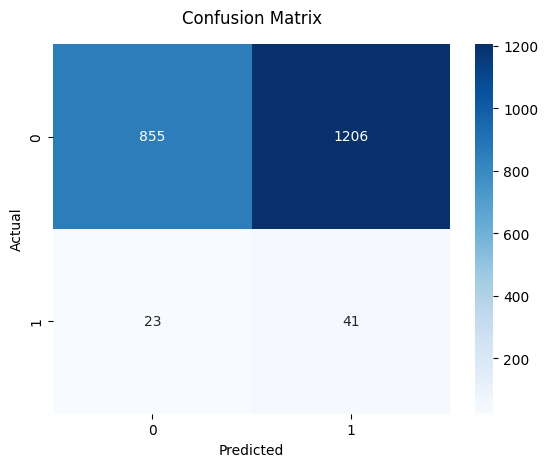

              precision    recall  f1-score   support

           0       0.97      0.41      0.58      2061
           1       0.03      0.64      0.06        64

    accuracy                           0.42      2125
   macro avg       0.50      0.53      0.32      2125
weighted avg       0.95      0.42      0.57      2125



In [184]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_test))
print("\n")

sns.heatmap(confusion_matrix(y_test, y_pred_test),
            annot=True,
            fmt='d',
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', pad = 15)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_test))



ROC Curve / AUC

<ipython-input-185-4e82e4c75293>:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color = "#ADD8E6")


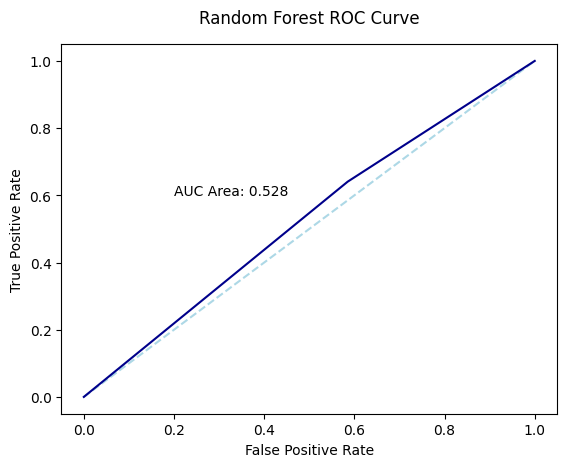



ROC AUC Area:  0.528


In [185]:
# Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.plot([0, 1], [0, 1], 'k--', color = "#ADD8E6")
plt.plot(fpr, tpr, color = "#00008B")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.annotate(f"AUC Area: {roc_auc_score(y_test, y_pred_test).round(3)}", xy = (0.2, 0.6))
plt.title('Random Forest ROC Curve', pad = 15)
plt.show()


# ROC AUC area
print("\n")
print("ROC AUC Area: ", roc_auc_score(y_test, y_pred_test).round(3))


#### Feature Importance

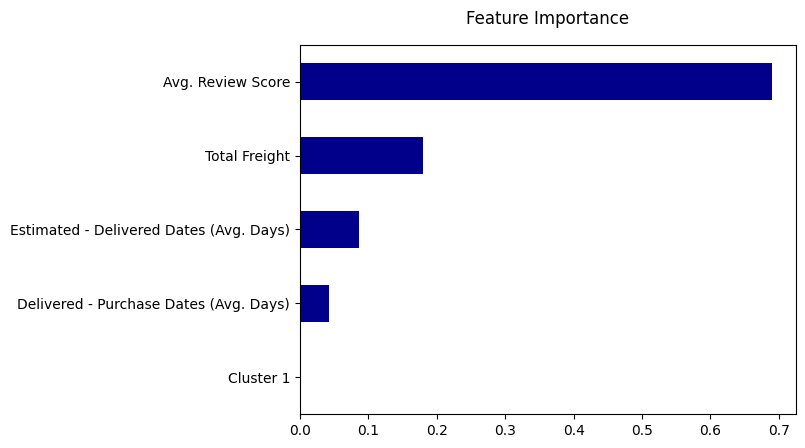

In [228]:
# Get the best pipeline
best_pipeline = cv_rf.best_estimator_

# Get the RandomForest model from the pipeline
random_forest_model = best_pipeline.named_steps["rf_model"]

# Get feature importances
feature_importances = random_forest_model.feature_importances_

# Get the feature names from the preprocessor's output.
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()

new_names = [
    "Cluster 1", "Estimated - Delivered Dates (Avg. Days)",\
    "Avg. Review Score", "Total Freight", "Delivered - Purchase Dates (Avg. Days)"]

# Create a pd.Series for feature importance
feature_importance_rf = pd.Series(
    feature_importances, index = new_names).sort_values()

# Plot
feature_importance_rf.plot(kind = "barh",
                           color = "#00008B")
plt.title("Feature Importance", pad = 15)
plt.show()


## Logistic Regression

### Import File

In [187]:
 # Upload the "features_table.csv" that was originated at the end of "ML_Olist_Data_Preparation".
 # Copy the path and paste inside de pd.read_csv function below
lr_df = pd.read_csv("/content/features_table.csv")

#set seed
seed = 123

In [188]:
# Change cluster type
lr_df["cluster"] = lr_df["cluster"].astype("O")

# Inspect
lr_df.info()
lr_df.isna().sum()

lr_df = lr_df[lr_df["pay_type"] != "0"]

lr_df["pay_type"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10703 entries, 0 to 10702
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  10703 non-null  object 
 1   retention           10703 non-null  int64  
 2   tt_product_qty      10703 non-null  int64  
 3   tt_freight          10703 non-null  float64
 4   avg_waiting_days    10703 non-null  float64
 5   avg_del_comp_days   10703 non-null  float64
 6   avg_review_score    10623 non-null  float64
 7   purch_d_n           10703 non-null  object 
 8   purch_wd            10703 non-null  object 
 9   pay_type            10702 non-null  object 
 10  sp_rj_mg_or_other   10703 non-null  object 
 11  cluster             10703 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 1003.5+ KB


,count
pay_type,
credit_card,8052
boleto,2311
voucher,234
debit_card,105


### Iteration 1 (Cross-Validation)



#### Features & Pipeline Creation

In [189]:
# Define numerical and categorical columns
numeric_features = ["tt_product_qty", "tt_freight", "avg_waiting_days", "avg_review_score"]
categorical_features = ["purch_d_n", "purch_wd", "pay_type", "sp_rj_mg_or_other", "cluster"]

In [190]:
# Creation ColumnTransformer to handle numeroc and categorical columns separately
preprocessor_mean = ColumnTransformer(
    transformers=[
        #Numeric pipeline: Impute missing values with mean, then scale
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        # Categorical pipeline: Only encode ( no imputation needed since there are no missing values)
        ("cat", Pipeline([
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) #handles unknown categories by setting their encoded values to all zeros
        ]), categorical_features)
    ]
)

In [191]:
#Logistic Regression Model w/class_weight="balanced"
model_balanced = LogisticRegression(random_state=seed, max_iter=250, class_weight="balanced")

#Create a Pipeline with the balanced model
pipeline_balanced_mean = Pipeline([
    ("preprocessor", preprocessor_mean),
    ("classifier", model_balanced)
])

#### Train-Test Split

In [192]:
# Creation of features
X = lr_df[numeric_features + categorical_features]
y = lr_df["retention"]

# Train-test split (80%/20%) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

#Fit the Pipeline
pipeline_balanced_mean.fit(X_train, y_train)

# Get predicted class labels for evaluation
y_pred_balanced_mean = pipeline_balanced_mean.predict(X_test)

#### Cross-Validation Test

In [193]:
#Cross-Validation Strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

#Define Scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "precision": make_scorer(precision_score, pos_label=1),
    "recall": make_scorer(recall_score, pos_label=1),
    "f1": make_scorer(f1_score, pos_label=1)
}

# Performe Cross-Validation
cv_results = cross_validate(pipeline_balanced_mean, X, y, cv=cv, scoring=scoring, return_train_score=False)

#Print the CV results
print("Cross-Validation Results (5-Fold):")
print(f"AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std() * 2:.4f})")
print(f"Precision (Retention): {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std() * 2:.4f})")
print(f"Recall (Retention): {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std() * 2:.4f})")
print(f"F1-Score (Retention): {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std() * 2:.4f})")

Cross-Validation Results (5-Fold):
AUC: 0.5455 (+/- 0.0523)
Precision (Retention): 0.0359 (+/- 0.0069)
Recall (Retention): 0.4874 (+/- 0.1329)
F1-Score (Retention): 0.0669 (+/- 0.0131)


##### Evaluation

In [194]:
# Evaluate the model
print("Model Accuracy (Test Set):", pipeline_balanced_mean.score(X_test, y_test))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced_mean))
print("Classification Report:")
print(classification_report(y_test, y_pred_balanced_mean, target_names=["No Retention", "Retention"]))
cm_balanced = (confusion_matrix(y_test, y_pred_balanced_mean))

Model Accuracy (Test Set): 0.588042970574498
Confusion Matrix:
[[1226  851]
 [  31   33]]
Classification Report:
              precision    recall  f1-score   support

No Retention       0.98      0.59      0.74      2077
   Retention       0.04      0.52      0.07        64

    accuracy                           0.59      2141
   macro avg       0.51      0.55      0.40      2141
weighted avg       0.95      0.59      0.72      2141



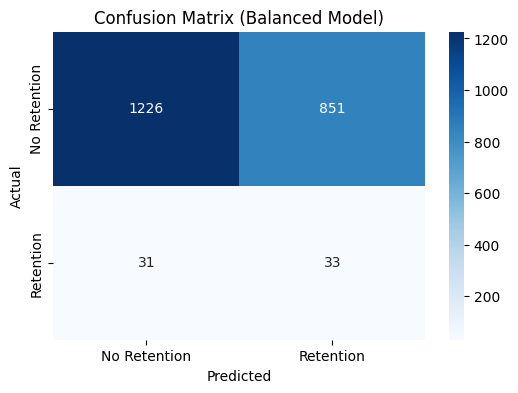

In [195]:
#Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_balanced, annot=True, fmt="d", cmap="Blues", xticklabels=["No Retention", "Retention"], yticklabels=["No Retention", "Retention"])
plt.title("Confusion Matrix (Balanced Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Feature Importance Analysis

In [196]:
#Compute permutation importance on the test set
perm_importance = permutation_importance(pipeline_balanced_mean, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=seed)

# Get the transformed feature names for categorical features (after OneHotEncoder)
cat_transformer = pipeline_balanced_mean.named_steps['preprocessor'].named_transformers_['cat']
cat_encoder = cat_transformer.named_steps['encoder']
categorical_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Combine numeric and categorical feature names
features = np.concatenate([numeric_features, categorical_feature_names])

# Ensure the features list matches the length of perm_importance.importances_mean
if len(features) != len(perm_importance.importances_mean):
    print(f"Warning: Length mismatch - features: {len(features)}, importances: {len(perm_importance.importances_mean)}")
    features = features[:len(perm_importance.importances_mean)]

In [197]:
# DataFrame of feature names and their importance
perm_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
})

# Sort by Importance
perm_importance_df = perm_importance_df.sort_values(by="Importance", ascending=False)

print("Feature Importance (Permutation Importance):")
print(perm_importance_df)

Feature Importance (Permutation Importance):
             Feature  Importance       Std
6  purch_wd_weekdays    0.022255  0.008465
3   avg_review_score    0.021096  0.010470
8    pay_type_boleto    0.012357  0.017098
0     tt_product_qty    0.006285  0.009646
4      purch_d_n_day    0.006144  0.004770
2   avg_waiting_days   -0.000043  0.006941
1         tt_freight   -0.000566  0.000896
7   purch_wd_weekend   -0.004819  0.004371
5    purch_d_n_night   -0.011748  0.003277


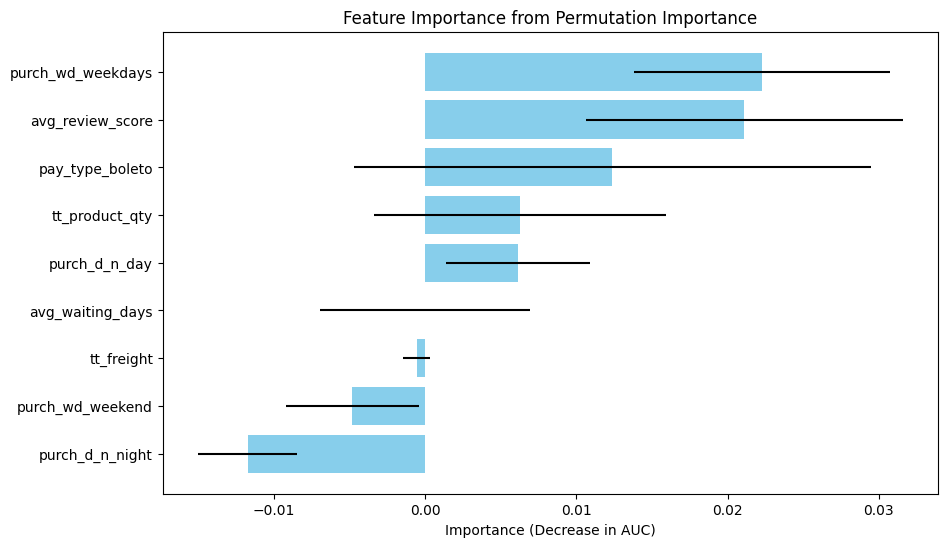

In [198]:
#Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["Feature"], perm_importance_df["Importance"], xerr=perm_importance_df["Std"], color="skyblue")
plt.xlabel("Importance (Decrease in AUC)")
plt.title("Feature Importance from Permutation Importance")
plt.gca().invert_yaxis()
plt.show()

####ROC Curve

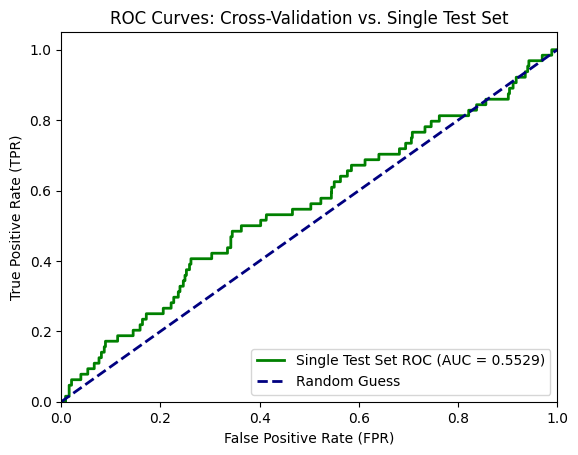

Single Test Set AUC: 0.5529


In [199]:
# Get predicted probabilities for the test set (for ROC curve)
y_pred_prob = pipeline_balanced_mean.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

# Single test set ROC curve
plt.plot(fpr, tpr, color="green", lw=2, label=f"Single Test Set ROC (AUC = {roc_auc:.4f})")
# Random guess line
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves: Cross-Validation vs. Single Test Set")
plt.legend(loc="lower right")
plt.show()

# Print the Single Test Set AUC

print(f"Single Test Set AUC: {roc_auc:.4f}")

### Iteration 2 (CV - Median)



#### Features & Pipeline Creation

In [200]:
# Define numerical and categorical columns
numeric_features = ["tt_product_qty", "tt_freight", "avg_waiting_days", "avg_review_score"]
categorical_features = ["purch_d_n", "purch_wd", "pay_type", "sp_rj_mg_or_other", "cluster"]

In [201]:
# Creation ColumnTransformer to handle numeroc and categorical columns separately
preprocessor_median = ColumnTransformer(
    transformers=[
        #Numeric pipeline: Impute missing values with mean, then scale
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        # Categorical pipeline: Only encode ( no imputation needed since there are no missing values)
        ("cat", Pipeline([
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) #handles unknown categories by setting their encoded values to all zeros
        ]), categorical_features)
    ]
)

In [202]:
#Logistic Regression Model
model_balanced = LogisticRegression(random_state=seed, max_iter=250, class_weight="balanced")

#Create a Pipeline with the balanced model
pipeline_balanced_median = Pipeline([
    ("preprocessor", preprocessor_median),
    ("classifier", model_balanced)
])

#### Train-Test Split

In [203]:
# Creation of features
X = lr_df[numeric_features + categorical_features]
y = lr_df["retention"]

# Train-test split (80%/20%) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

#Fit the Pipeline
pipeline_balanced_median.fit(X_train, y_train)

# Get predicted class labels for evaluation
y_pred_balanced_median = pipeline_balanced_median.predict(X_test)

#### Cross-Validation Test

In [204]:
#Cross-Validation Strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

#Define Scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "precision": make_scorer(precision_score, pos_label=1),
    "recall": make_scorer(recall_score, pos_label=1),
    "f1": make_scorer(f1_score, pos_label=1)
}

# Performe Cross-Validation
cv_results = cross_validate(pipeline_balanced_median, X, y, cv=cv, scoring=scoring, return_train_score=False)

#Print the results
print("Cross-Validation Results (5-Fold):")
print(f"AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std() * 2:.4f})")
print(f"Precision (Retention): {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std() * 2:.4f})")
print(f"Recall (Retention): {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std() * 2:.4f})")
print(f"F1-Score (Retention): {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std() * 2:.4f})")

Cross-Validation Results (5-Fold):
AUC: 0.5457 (+/- 0.0539)
Precision (Retention): 0.0359 (+/- 0.0068)
Recall (Retention): 0.4874 (+/- 0.1329)
F1-Score (Retention): 0.0669 (+/- 0.0131)


##### Evaluation

In [205]:
# Evaluate the model
print("Balanced Model Accuracy (Test Set):", pipeline_balanced_median.score(X_test, y_test))
print("Balanced Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced_median))
print("Balanced Classification Report:")
print(classification_report(y_test, y_pred_balanced_median, target_names=["No Retention", "Retention"]))
cm_balanced = (confusion_matrix(y_test, y_pred_balanced_median))

Balanced Model Accuracy (Test Set): 0.5875758991125642
Balanced Confusion Matrix:
[[1225  852]
 [  31   33]]
Balanced Classification Report:
              precision    recall  f1-score   support

No Retention       0.98      0.59      0.74      2077
   Retention       0.04      0.52      0.07        64

    accuracy                           0.59      2141
   macro avg       0.51      0.55      0.40      2141
weighted avg       0.95      0.59      0.72      2141



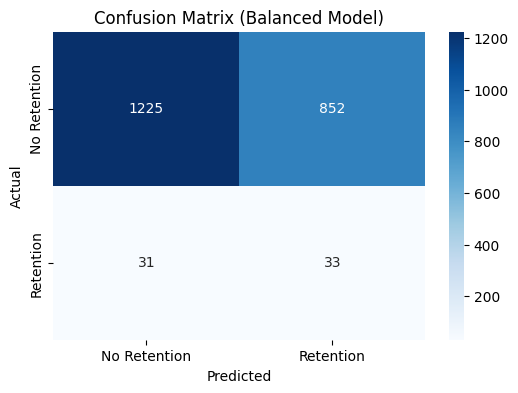

In [206]:
#Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_balanced, annot=True, fmt="d", cmap="Blues", xticklabels=["No Retention", "Retention"], yticklabels=["No Retention", "Retention"])
plt.title("Confusion Matrix (Balanced Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Comparison between Mean vs Median

In [207]:
#Accuracy Score Comparison
accuracy_mean = accuracy_score(y_test, y_pred_balanced_mean)
accuracy_median = accuracy_score(y_test, y_pred_balanced_median)

# Compute accuracy
print("### Accuracy")
print(f"Mean Imputation Accuracy: {accuracy_mean:.4f}")
print(f"Median Imputation Accuracy: {accuracy_median:.4f}")
print(f"Difference (Median - Mean): {(accuracy_median - accuracy_mean):.4f}\n")

# Compute confusion matrices
cm_mean = confusion_matrix(y_test, y_pred_balanced_mean)
cm_median = confusion_matrix(y_test, y_pred_balanced_median)

# Compute classification reports as dictionaries
report_mean = classification_report(y_test, y_pred_balanced_mean, target_names=["No Retention", "Retention"], output_dict=True)
report_median = classification_report(y_test, y_pred_balanced_median, target_names=["No Retention", "Retention"], output_dict=True)

# Compute ROC AUC
roc_auc_mean = roc_auc_score(y_test, y_pred_balanced_mean)
roc_auc_median = roc_auc_score(y_test, y_pred_balanced_median)

# Print Results
print("## Comparison of Mean vs. Median Imputation\n")

# Accuracy
print("### Accuracy")
print(f"Mean Imputation Accuracy: {accuracy_mean:.4f}")
print(f"Median Imputation Accuracy: {accuracy_median:.4f}")
print(f"Difference (Median - Mean): {(accuracy_median - accuracy_mean):.4f}\n")

# Confusion Matrices
print("### Confusion Matrices")
print("Mean Imputation Confusion Matrix:")
print(cm_mean)
print("\nMedian Imputation Confusion Matrix:")
print(cm_median)
print("\nDifference (Median - Mean):")
print(cm_median - cm_mean)

# Classification Report Comparison
print("### Classification Report Comparison")
print("#### Retention")
print(f"Precision (Mean): {report_mean['Retention']['precision']:.2f}")
print(f"Precision (Median): {report_median['Retention']['precision']:.2f}")
print(f"Difference (Median - Mean): {(report_median['Retention']['precision'] - report_mean['Retention']['precision']):+.2f}")
print(f"Recall (Mean): {report_mean['Retention']['recall']:.2f}")
print(f"Recall (Median): {report_median['Retention']['recall']:.2f}")
print(f"Difference (Median - Mean): {(report_median['Retention']['recall'] - report_mean['Retention']['recall']):+.2f}")
print(f"F1-Score (Mean): {report_mean['Retention']['f1-score']:.2f}")
print(f"F1-Score (Median): {report_median['Retention']['f1-score']:.2f}")
print(f"Difference (Median - Mean): {(report_median['Retention']['f1-score'] - report_mean['Retention']['f1-score']):+.2f}\n")


### Accuracy
Mean Imputation Accuracy: 0.5880
Median Imputation Accuracy: 0.5876
Difference (Median - Mean): -0.0005

## Comparison of Mean vs. Median Imputation

### Accuracy
Mean Imputation Accuracy: 0.5880
Median Imputation Accuracy: 0.5876
Difference (Median - Mean): -0.0005

### Confusion Matrices
Mean Imputation Confusion Matrix:
[[1226  851]
 [  31   33]]

Median Imputation Confusion Matrix:
[[1225  852]
 [  31   33]]

Difference (Median - Mean):
[[-1  1]
 [ 0  0]]
### Classification Report Comparison
#### Retention
Precision (Mean): 0.04
Precision (Median): 0.04
Difference (Median - Mean): -0.00
Recall (Mean): 0.52
Recall (Median): 0.52
Difference (Median - Mean): +0.00
F1-Score (Mean): 0.07
F1-Score (Median): 0.07
Difference (Median - Mean): -0.00



#### Feature Importance Analysis

In [208]:
#Compute permutation importance on the test set
perm_importance = permutation_importance(pipeline_balanced_median, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=seed)

# Get the transformed feature names for categorical features (after OneHotEncoder)
cat_transformer = pipeline_balanced_median.named_steps['preprocessor'].named_transformers_['cat']
cat_encoder = cat_transformer.named_steps['encoder']
categorical_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Combine numeric and categorical feature names
features = np.concatenate([numeric_features, categorical_feature_names])

# Ensure the features list matches the length of perm_importance.importances_mean
if len(features) != len(perm_importance.importances_mean):
    print(f"Warning: Length mismatch - features: {len(features)}, importances: {len(perm_importance.importances_mean)}")
    features = features[:len(perm_importance.importances_mean)]

In [209]:
# DataFrame of feature names and their importance
perm_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
})

# Sort by Importance
perm_importance_df = perm_importance_df.sort_values(by="Importance", ascending=False)

print("Feature Importance (Permutation Importance):")
print(perm_importance_df)

Feature Importance (Permutation Importance):
             Feature  Importance       Std
6  purch_wd_weekdays    0.022204  0.008425
3   avg_review_score    0.019917  0.010425
8    pay_type_boleto    0.012284  0.017034
0     tt_product_qty    0.006152  0.009614
4      purch_d_n_day    0.005946  0.004722
2   avg_waiting_days   -0.000243  0.006970
1         tt_freight   -0.000785  0.000923
7   purch_wd_weekend   -0.004996  0.004363
5    purch_d_n_night   -0.011861  0.003269


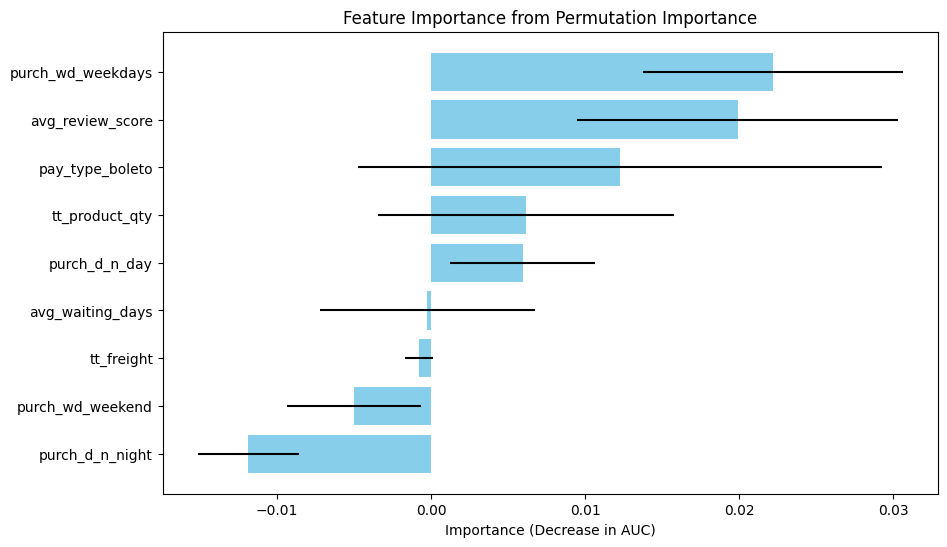

In [210]:
#Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["Feature"], perm_importance_df["Importance"], xerr=perm_importance_df["Std"], color="skyblue")
plt.xlabel("Importance (Decrease in AUC)")
plt.title("Feature Importance from Permutation Importance")
plt.gca().invert_yaxis()
plt.show()

####ROC Curve

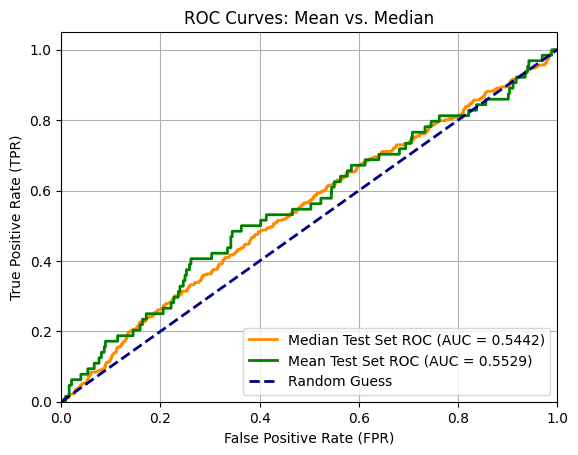

Mean AUC: 0.5442
Median AUC: 0.5529


In [211]:
# Get predicted probabilities Mean Imputer for the test set (for ROC curve)
y_pred_prob_mean = pipeline_balanced_mean.predict_proba(X_test)[:, 1]

# Cross-validated predicted probabilities Median Imputer for the entire dataset
y_pred_prob_median = cross_val_predict(pipeline_balanced_median, X, y, cv=cv, method="predict_proba")[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

# Compute the ROC curve and AUC for the cross-validated predictions
fpr_median, tpr_median, thresholds_median = roc_curve(y, y_pred_prob_median, pos_label=1)
roc_auc_median = auc(fpr_median, tpr_median)

# Median Imputer ROC curve
plt.plot(fpr_median, tpr_median, color="darkorange", lw=2, label=f"Median Test Set ROC (AUC = {roc_auc_median:.4f})")

# Single test set ROC curve
plt.plot(fpr, tpr, color="green", lw=2, label=f"Mean Test Set ROC (AUC = {roc_auc:.4f})")

# Random guess line
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves: Mean vs. Median")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Print the AUCs for clarity
print(f"Mean AUC: {roc_auc_median:.4f}")
print(f"Median AUC: {roc_auc:.4f}")

### Iteration 3 (Hyperparameterization)



#### Features & Pipeline Creation

In [212]:
# Define numerical and categorical columns
numeric_features = ["tt_product_qty", "tt_freight", "avg_waiting_days", "avg_review_score"]
categorical_features = ["purch_d_n", "purch_wd", "pay_type", "sp_rj_mg_or_other", "cluster"]

In [213]:
# Creation ColumnTransformer to handle numeroc and categorical columns separately
preprocessor_median = ColumnTransformer(
    transformers=[
        #Numeric pipeline: Impute missing values with Median, then scale
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        # Categorical pipeline: Only encode ( no imputation needed since there are no missing values)
        ("cat", Pipeline([
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) #handles unknown categories by setting their encoded values to all zeros
        ]), categorical_features)
    ]
)

In [214]:
#Logistic Regression Model
model_balanced = LogisticRegression(random_state=seed, max_iter=250, class_weight="balanced")

#Create a Pipeline with the balanced model
pipeline_balanced_median = Pipeline([
    ("preprocessor", preprocessor_median),
    ("classifier", model_balanced)
])

#### Train-Test Split

In [215]:
# Creation of features
X = lr_df[numeric_features + categorical_features]
y = lr_df["retention"]

# Train-test split (80%/20%) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=seed,
                                                    stratify=y)

#### CV RandomizedSearch Test

In [216]:
# Define hyperparameter grid
param_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.001, 0.01, 0.1, 1, 10],
        "classifier__class_weight": ["balanced", {0:1, 1:10}, {0:1, 1:20}]
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.001, 0.01, 0.1, 1, 10],
        "classifier__class_weight": ["balanced", {0:1, 1:10}, {0:1, 1:20}]
    }
]

# Cross-validation strategy for hyperparameter tuning
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline_balanced_median,
    param_distributions=param_grid,
    n_iter=20,  # Number of parameter settings to sample
    scoring="recall",  # Optimize for recall of Retention class
    cv=cv_tune,
    random_state=seed,
    n_jobs=-1  # Use all available cores
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Hyperparameters:", random_search.best_params_)
print("Best Cross-Validation Recall (Retention):", random_search.best_score_.round(4))

# Get the best model
best_pipeline = random_search.best_estimator_

Best Hyperparameters: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l1', 'classifier__class_weight': 'balanced', 'classifier__C': 0.01}
Best Cross-Validation Recall (Retention): 0.6206


#### CV Test with the Best Model

In [217]:
# Cross-Validation Strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Define Scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "precision": make_scorer(precision_score, pos_label=1),
    "recall": make_scorer(recall_score, pos_label=1),
    "f1": make_scorer(f1_score, pos_label=1)
}

# Perform Cross-Validation with the best model
cv_results = cross_validate(best_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Print the results
print("\nCross-Validation Results (5-Fold) with Best Model:")
print(f"AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std() * 2:.4f})")
print(f"Precision (Retention): {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std() * 2:.4f})")
print(f"Recall (Retention): {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std() * 2:.4f})")
print(f"F1-Score (Retention): {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std() * 2:.4f})")


Cross-Validation Results (5-Fold) with Best Model:
AUC: 0.5475 (+/- 0.0497)
Precision (Retention): 0.0340 (+/- 0.0051)
Recall (Retention): 0.5897 (+/- 0.1789)
F1-Score (Retention): 0.0642 (+/- 0.0083)


##### Evaluation

In [218]:
# Evaluate the model
print("\nBalanced Model Accuracy (Test Set):", best_pipeline.score(X_test, y_test))
print("Balanced Confusion Matrix:")
cm_balanced = confusion_matrix(y_test, y_pred_balanced_median)
print(cm_balanced)
print("Balanced Classification Report:")
print(classification_report(y_test, y_pred_balanced_median, target_names=["No Retention", "Retention"]))


Balanced Model Accuracy (Test Set): 0.6282111163007941
Balanced Confusion Matrix:
[[1225  852]
 [  31   33]]
Balanced Classification Report:
              precision    recall  f1-score   support

No Retention       0.98      0.59      0.74      2077
   Retention       0.04      0.52      0.07        64

    accuracy                           0.59      2141
   macro avg       0.51      0.55      0.40      2141
weighted avg       0.95      0.59      0.72      2141



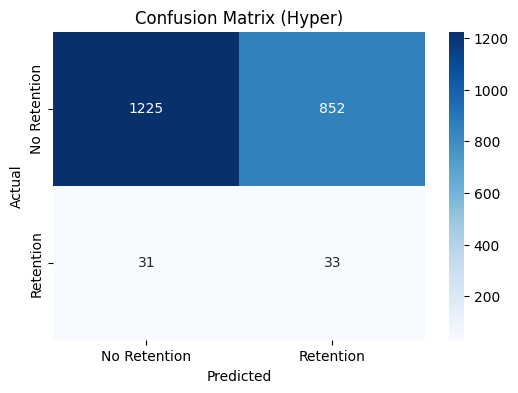

In [219]:
# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_balanced, annot=True, fmt="d", cmap="Blues", xticklabels=["No Retention", "Retention"], yticklabels=["No Retention", "Retention"])
plt.title("Confusion Matrix (Hyper)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### ROC Curve with Best Model

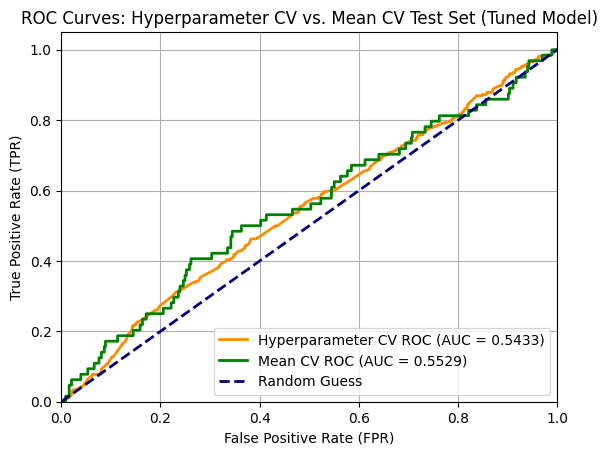

Hyperparameter CV AUC: 0.5433
Single Test Set AUC: 0.5529


In [225]:
# Get predicted probabilities for the test set (for ROC curve)
y_pred_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Hyperparameterization predicted probabilities for the entire dataset
y_pred_prob_hyper = cross_val_predict(best_pipeline, X, y, cv=cv, method="predict_proba")[:, 1]

# Compute Mean Imputer ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_mean, pos_label=1)
roc_auc = auc(fpr, tpr)

# Compute the ROC curve and AUC for the Hyperparameterization predictions
fpr_hyper, tpr_hyper, thresholds_hyper = roc_curve(y, y_pred_prob_hyper, pos_label=1)
roc_auc_hyper = auc(fpr_hyper, tpr_hyper)

# Cross-validation ROC curve
plt.plot(fpr_hyper, tpr_hyper, color="darkorange", lw=2, label=f"Hyperparameter CV ROC (AUC = {roc_auc_hyper:.4f})")

# Single test set ROC curve
plt.plot(fpr, tpr, color="green", lw=2, label=f"Mean CV ROC (AUC = {roc_auc:.4f})")

# Random guess line
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves: Hyperparameter CV vs. Mean CV Test Set (Tuned Model)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Print the AUCs for clarity
print(f"Hyperparameter CV AUC: {roc_auc_hyper:.4f}")
print(f"Single Test Set AUC: {roc_auc:.4f}")